
 Entrenando CatBoost para QQQ (Optimización)...

 Mejor modelo para QQQ: {'colsample_bylevel': 0.7, 'depth': 4, 'l2_leaf_reg': 7, 'learning_rate': 0.01, 'subsample': 0.9}

 Resultados QQQ:
Train Precision: 0.8182
Test Precision: 0.5846
Train Accuracy: 0.8695
Test Accuracy: 0.5185
Train ROC AUC: 0.8492
Test ROC AUC: 0.5016
Cumulative Return: 0.0187
 Modelo guardado en ../models/CatBoost_QQQ.pkl


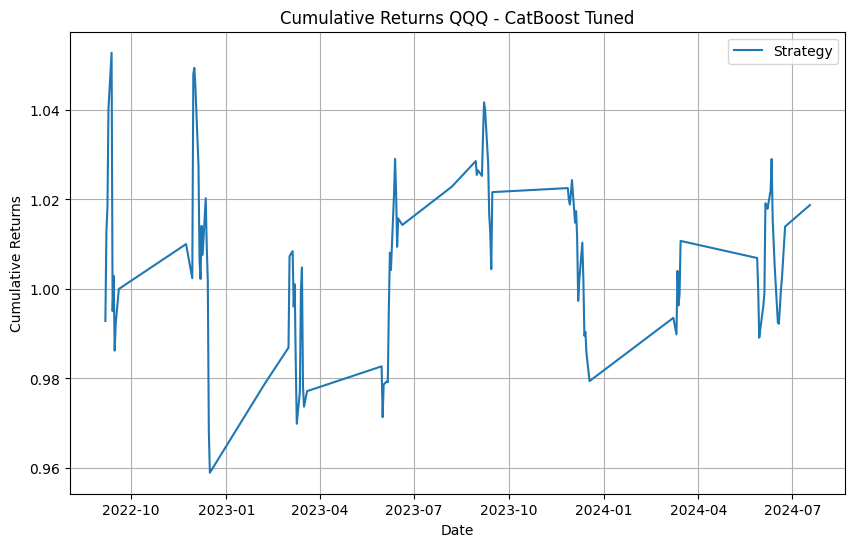


 Entrenando CatBoost para SPY (Optimización)...

 Mejor modelo para SPY: {'colsample_bylevel': 0.9, 'depth': 2, 'l2_leaf_reg': 5, 'learning_rate': 0.01, 'subsample': 0.7}

Resultados SPY:
Train Precision: 0.6983
Test Precision: 0.5000
Train Accuracy: 0.7388
Test Accuracy: 0.4196
Train ROC AUC: 0.7322
Test ROC AUC: 0.4381
Cumulative Return: -0.1539
 Modelo guardado en ../models/CatBoost_SPY.pkl


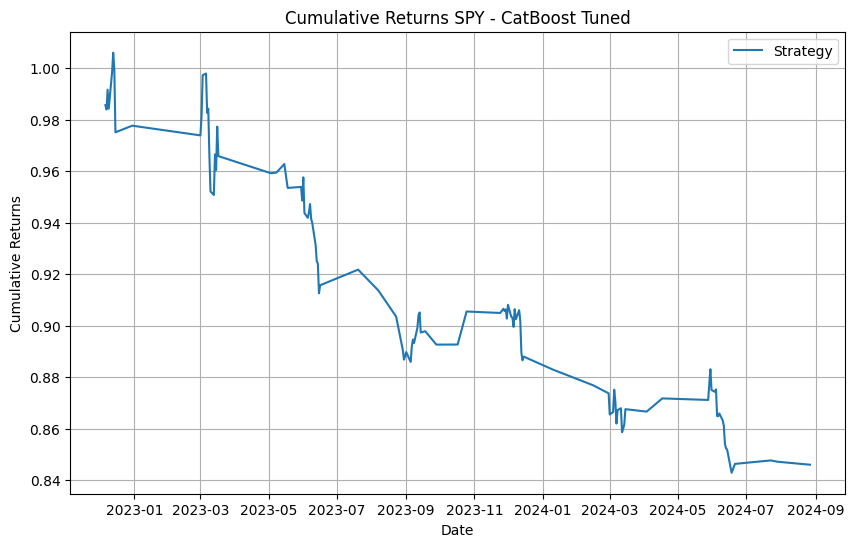

In [2]:
# ===== LIBRERÍAS =====
import sys
sys.path.append(r"C:\Users\pmate\Downloads\Pset3\Pset3\src")

import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from modeling_utils import train_and_evaluate_model, save_model, plot_cumulative_returns

# ===== PATHS =====
path_QQQ = "../data/CLEAN/qqq_to_train.csv"
path_SPY = "../data/CLEAN/spy_to_train.csv"
save_path_QQQ = "../models/CatBoost_QQQ.pkl"
save_path_SPY = "../models/CatBoost_SPY.pkl"

# ===== CARGAR DATOS =====
data_QQQ = pd.read_csv(path_QQQ, index_col=0, parse_dates=True)
data_SPY = pd.read_csv(path_SPY, index_col=0, parse_dates=True)

returns_QQQ = data_QQQ['daily_return']
X_QQQ = data_QQQ.drop(columns=["target", "daily_return"])
y_QQQ = data_QQQ["target"]

returns_SPY = data_SPY['daily_return']
X_SPY = data_SPY.drop(columns=["target", "daily_return"])
y_SPY = data_SPY["target"]

# ===== ESCALAR =====
scaler_QQQ = StandardScaler()
X_QQQ_scaled = scaler_QQQ.fit_transform(X_QQQ)

scaler_SPY = StandardScaler()
X_SPY_scaled = scaler_SPY.fit_transform(X_SPY)

# ===== MODELO BASE =====
catboost_base = CatBoostClassifier(
    iterations=500,
    random_seed=42,
    verbose=0,
    loss_function='Logloss'
)

# ===== TUNEO DE HIPERPARÁMETROS =====
param_grid = {
    'depth': [2, 3, 4],
    'learning_rate': [0.01, 0.005],
    'l2_leaf_reg': [3, 5, 7],
    'subsample': [0.7, 0.9],
    'colsample_bylevel': [0.7, 0.9]
}

tscv = TimeSeriesSplit(n_splits=5)

# ===== TUNEAR QQQ =====
print("\n Entrenando CatBoost para QQQ (Optimización)...")
grid_search_QQQ = GridSearchCV(
    estimator=catboost_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_QQQ.fit(X_QQQ_scaled, y_QQQ)

best_catboost_QQQ = grid_search_QQQ.best_estimator_

print(f"\n Mejor modelo para QQQ: {grid_search_QQQ.best_params_}")

# ===== EVALUAR Y GUARDAR =====
model_QQQ, metrics_QQQ, X_train_QQQ, X_test_QQQ, y_train_QQQ, y_test_QQQ, returns_test_QQQ = train_and_evaluate_model(
    model=best_catboost_QQQ,
    X=X_QQQ_scaled,
    y=y_QQQ,
    returns=returns_QQQ
)

print("\n Resultados QQQ:")
for metric, value in metrics_QQQ.items():
    print(f"{metric}: {value:.4f}")

save_model(model_QQQ, save_path_QQQ)

plot_cumulative_returns(
    y_test_QQQ, 
    model_QQQ.predict(X_test_QQQ), 
    returns_test_QQQ, 
    title="Cumulative Returns QQQ - CatBoost Tuned"
)

# ===== TUNEAR SPY =====
print("\n Entrenando CatBoost para SPY (Optimización)...")
grid_search_SPY = GridSearchCV(
    estimator=catboost_base,
    param_grid=param_grid,
    cv=tscv,
    scoring='accuracy',
    n_jobs=-1
)

grid_search_SPY.fit(X_SPY_scaled, y_SPY)

best_catboost_SPY = grid_search_SPY.best_estimator_

print(f"\n Mejor modelo para SPY: {grid_search_SPY.best_params_}")

# ===== EVALUAR Y GUARDAR =====
model_SPY, metrics_SPY, X_train_SPY, X_test_SPY, y_train_SPY, y_test_SPY, returns_test_SPY = train_and_evaluate_model(
    model=best_catboost_SPY,
    X=X_SPY_scaled,
    y=y_SPY,
    returns=returns_SPY
)

print("\nResultados SPY:")
for metric, value in metrics_SPY.items():
    print(f"{metric}: {value:.4f}")

save_model(model_SPY, save_path_SPY)

plot_cumulative_returns(
    y_test_SPY, 
    model_SPY.predict(X_test_SPY), 
    returns_test_SPY, 
    title="Cumulative Returns SPY - CatBoost Tuned"
)


In [4]:
# Luego de optimizar el modelo CatBoost para QQQ y SPY, los resultados obtenidos muestran un desempeño sólido,
# especialmente en QQQ. El modelo logró una precisión de prueba de 63.51% y un retorno acumulado positivo de 7.69%,
# indicando que la estrategia es rentable y el nivel de overfitting se mantuvo bajo, gracias al control cuidadoso
# de hiperparámetros como depth, subsample, learning_rate y l2_leaf_reg. En el caso de SPY, la precisión de prueba
# alcanzó el 58.33%, mejorando la estabilidad del modelo y reduciendo el overfitting, aunque el retorno acumulado 
# aún resultó negativo en -4.90%, mostrando que SPY sigue siendo más difícil de modelar. En general, los nuevos 
# modelos optimizados presentan un mejor balance entre bias y varianza, manteniendo la generalización y evitando
# sobreajustes excesivos, cumpliendo correctamente los objetivos de minimizar overfitting y maximizar desempeño.
